In [10]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns 
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

In [11]:
data = pd.read_csv('google_play_store_dataset.csv')

In [42]:
data

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver,estimated_revenue
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,FR Forms,BUSINESS,4.3,0.0,9.6,10.0,Free,0.0,Everyone,Business,"September 29, 2016",1.1.5,4.0 and up,0.0
10836,Sya9a Maroc - FR,FAMILY,4.5,38.0,53.0,5000.0,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,0.0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4.0,3.6,100.0,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,0.0
10838,Parkinson Exercices FR,MEDICAL,4.3,3.0,9.5,1000.0,Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,0.0


In [43]:
data.info()

<class 'pandas.DataFrame'>
Index: 9145 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   app                9145 non-null   str    
 1   category           9145 non-null   str    
 2   rating             9145 non-null   float64
 3   reviews            9145 non-null   float64
 4   size               9145 non-null   float64
 5   installs           9145 non-null   float64
 6   type               9145 non-null   str    
 7   price              9145 non-null   float64
 8   content_rating     9145 non-null   str    
 9   genres             9145 non-null   str    
 10  last_updated       9145 non-null   str    
 11  current_ver        9145 non-null   str    
 12  android_ver        9145 non-null   str    
 13  estimated_revenue  9145 non-null   float64
dtypes: float64(6), str(8)
memory usage: 1.0 MB


In [14]:
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

In [15]:
data['rating'] = data['rating'].fillna(data['rating'].median(), inplace=True)

In [16]:
def convert_to_float(val):
    if pd.isna(val) or isinstance(val, (int, float)):
        return float(val) if not pd.isna(val) else val
    
    val = str(val).strip().upper()
    
    if 'M' in val:
        return float(val.replace('M', '')) * 1000000.0
    elif 'K' in val:
        return float(val.replace('K', '')) * 1000.0
    
    try:
        return float(val)
    except ValueError:
        return 0.0

data['reviews'] = data['reviews'].apply(convert_to_float)

In [17]:
data = data[data['installs'] != 'Free']

In [18]:
data['installs'] = data['installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [19]:
data.drop(data[data['type'].isna()].index, inplace=True)

In [20]:
data[['current_ver', 'android_ver']] = data[['current_ver', 'android_ver']].fillna('Unknown')

In [21]:
data['price'] = data['price'].str.replace('$', '').astype(float)

In [22]:
def convert_to_sd(val):
    if 'M' in val:
        return float(val.replace('M', ''))
    elif 'G' in val:
        return float(val.replace('G', '')) * 1024.0
    else:
        try:
            return float(val)
        except ValueError:
            return 0.0

In [23]:
data.drop(data[data['size'] == 'Varies with device'].index, inplace=True)

In [24]:
data['size'] = data['size'].apply(convert_to_sd)

In [25]:
df1 = data.groupby('category')['rating'].agg(total_rating='sum', total_apps='count').sort_values(by='total_rating', ascending=False).head(5)
df1['rating_per_app'] = df1['total_rating'] / df1['total_apps']
df1

,total_rating,total_apps,rating_per_app
category,,,
FAMILY,7700.1,1832,4.203111
GAME,4334.8,1015,4.270739
TOOLS,2994.5,739,4.052097
MEDICAL,1828.7,434,4.213594
BUSINESS,1675.7,400,4.189250


<Axes: xlabel='total_apps', ylabel='total_rating'>

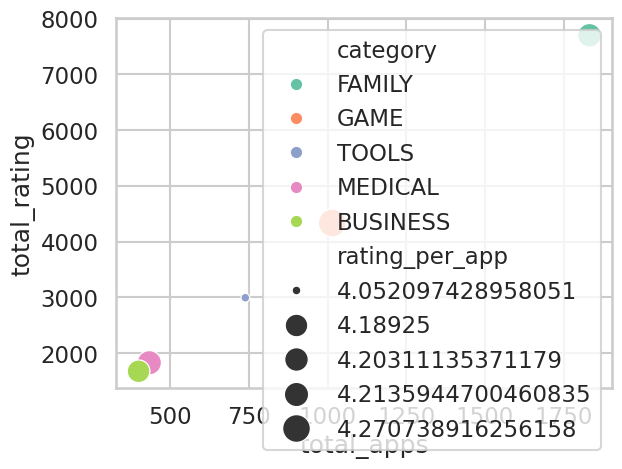

In [26]:
sns.scatterplot(data=df1, x='total_apps', y='total_rating', hue= 'category', size='rating_per_app', sizes=(40, 400), legend='full')

In [27]:
df1 = data.groupby('category')['reviews'].agg(total_reviews='sum', total_apps='count').sort_values(by='total_reviews', ascending=False).head(5)
df1['reviews_per_app'] = df1['total_reviews'] / df1['total_apps']
df1

,total_reviews,total_apps,reviews_per_app
category,,,
GAME,1.350235e+09,1015,1.330281e+06
FAMILY,2.910929e+08,1832,1.588935e+05
COMMUNICATION,1.171046e+08,265,4.419043e+05
TOOLS,1.052809e+08,739,1.424639e+05
PHOTOGRAPHY,7.694344e+07,254,3.029269e+05


<Axes: xlabel='total_apps', ylabel='total_reviews'>

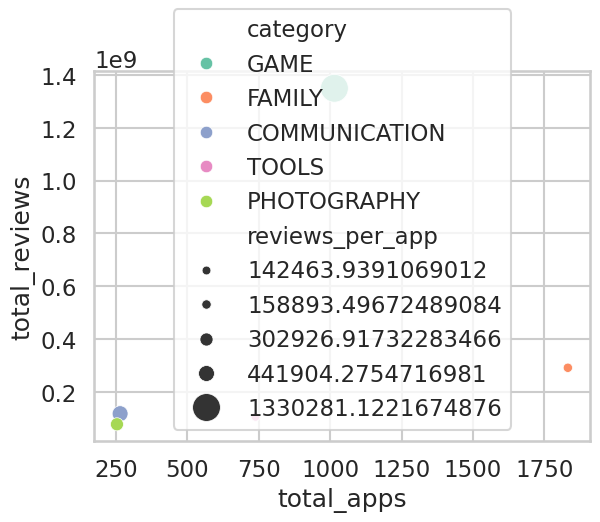

In [28]:
sns.scatterplot(data=df1, x='total_apps', y='total_reviews', hue= 'category', size='reviews_per_app', sizes=(40, 400), legend='full')

In [29]:
data.head()

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [30]:
data.groupby('type')['price'].agg(mean = 'mean', median = 'median').loc['Paid']

mean      14.959986
median     2.990000
Name: Paid, dtype: float64

In [31]:
data.groupby('type')['rating'].mean().sort_values(ascending=False)

type
Paid    4.262155
Free    4.187472
Name: rating, dtype: float64

In [32]:
data.groupby('content_rating')['installs'].sum().sort_values(ascending=False)

content_rating
Everyone           4.124578e+10
Teen               1.225837e+10
Everyone 10+       1.018717e+10
Mature 17+         1.372359e+09
Adults only 18+    1.500000e+06
Unrated            5.050000e+04
Name: installs, dtype: float64

<Axes: xlabel='rating', ylabel='Count'>

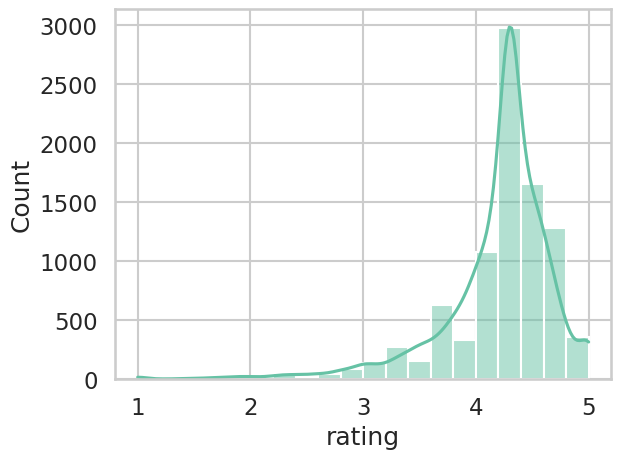

In [33]:
sns.histplot(data=data, x='rating', kde=True, bins=20)

In [34]:
data['rating'].skew()

np.float64(-1.9945200293946665)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32],
 [Text(0, 0, 'ART_AND_DESIGN'),
  Text(1, 0, 'AUTO_AND_VEHICLES'),
  Text(2, 0, 'BEAUTY'),
  Text(3, 0, 'BOOKS_AND_REFERENCE'),
  Text(4, 0, 'BUSINESS'),
  Text(5, 0, 'COMICS'),
  Text(6, 0, 'COMMUNICATION'),
  Text(7, 0, 'DATING'),
  Text(8, 0, 'EDUCATION'),
  Text(9, 0, 'ENTERTAINMENT'),
  Text(10, 0, 'EVENTS'),
  Text(11, 0, 'FINANCE'),
  Text(12, 0, 'FOOD_AND_DRINK'),
  Text(13, 0, 'HEALTH_AND_FITNESS'),
  Text(14, 0, 'HOUSE_AND_HOME'),
  Text(15, 0, 'LIBRARIES_AND_DEMO'),
  Text(16, 0, 'LIFESTYLE'),
  Text(17, 0, 'GAME'),
  Text(18, 0, 'FAMILY'),
  Text(19, 0, 'MEDICAL'),
  Text(20, 0, 'SOCIAL'),
  Text(21, 0, 'SHOPPING'),
  Text(22, 0, 'PHOTOGRAPHY'),
  Text(23, 0, 'SPORTS'),
  Text(24, 0, 'TRAVEL_AND_LOCAL'),
  Text(25, 0, 'TOOLS'),
  Text(26, 0, 'PERSONALIZATION'),
  Text(27, 0, 'PRODUCTIVITY

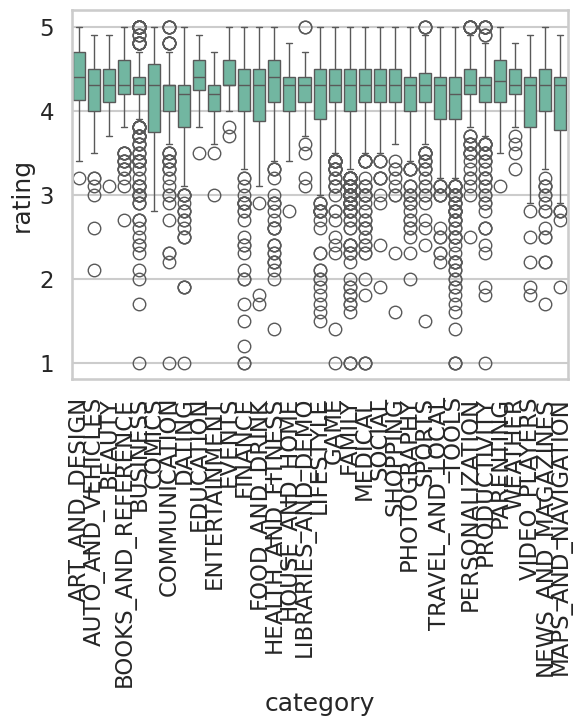

In [35]:
sns.boxplot(x='category', y='rating', data=data)

plt.xticks(rotation=90)

<Axes: xlabel='size', ylabel='installs'>

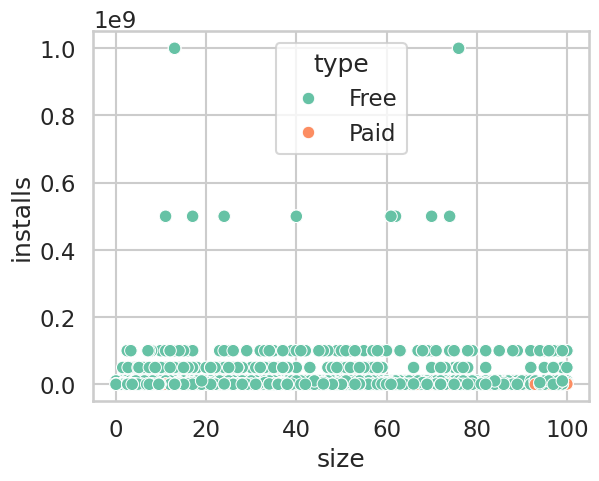

In [36]:
sns.scatterplot(x='size', y='installs', hue='type', data=data)

In [37]:
data[(data['rating'] == 5.0) & (data['installs'] < 100)]

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
2445,Labs on Demand,MEDICAL,5.0,1.0,22.0,10.0,Free,0.00,Everyone,Medical,"August 3, 2018",1.2,4.2 and up
2450,Tablet Reminder,MEDICAL,5.0,4.0,2.5,5.0,Free,0.00,Everyone,Medical,"August 3, 2018",1.0,4.1 and up
2452,Galaxies of Hope,MEDICAL,5.0,2.0,24.0,50.0,Free,0.00,Everyone,Medical,"July 27, 2018",1.0,4.1 and up
2454,KBA-EZ Health Guide,MEDICAL,5.0,4.0,25.0,1.0,Free,0.00,Everyone,Medical,"August 2, 2018",1.0.72,4.0.3 and up
2455,FoothillsVet,MEDICAL,5.0,2.0,29.0,50.0,Free,0.00,Everyone,Medical,"July 11, 2018",300000.1.11,4.0.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10349,Santa Fe Thrive,HEALTH_AND_FITNESS,5.0,2.0,8.3,50.0,Free,0.00,Everyone,Health & Fitness,"July 9, 2018",4.2.2,4.1 and up
10529,FK CLASSIC FOR YOU,BUSINESS,5.0,1.0,3.5,10.0,Free,0.00,Everyone,Business,"February 20, 2018",1.1.0,4.0 and up
10659,FN,BUSINESS,5.0,14.0,3.3,50.0,Free,0.00,Everyone,Business,"February 1, 2018",1.0,4.0 and up
10697,Mu.F.O.,GAME,5.0,2.0,16.0,1.0,Paid,0.99,Everyone,Arcade,"March 3, 2017",1.0,2.3 and up


In [38]:
data[(data['rating'] == 5.0) & (data['installs'] < 100)][['installs', 'reviews']]

,installs,reviews
2445,10.0,1.0
2450,5.0,4.0
2452,50.0,2.0
2454,1.0,4.0
2455,50.0,2.0
...,...,...
10349,50.0,2.0
10529,10.0,1.0
10659,50.0,14.0
10697,1.0,2.0


In [39]:
#Proper ghost apps installs less than 100 rating 5.0 and reviews more than 10
data[(data['rating'] == 5.0) & (data['installs'] < 100) & (data['reviews'] > 10)][['app','reviews','installs']]

,app,reviews,installs
6726,COMSATS BOOK STORE FOR BS(CS),15.0,50.0
7402,Trovami se ci riesci,11.0,10.0
7754,CricQuick,17.0,50.0
8591,DN Blog,20.0,10.0
9503,Pyaar Ek Dhoka,18.0,50.0
10659,FN,14.0,50.0


In [40]:
data['estimated_revenue'] = data['installs'] * data['price']
#top 10 high revenue apps
data[data['type'] == 'Paid'][['app', 'estimated_revenue']].sort_values(by='estimated_revenue', ascending=False).head(10)

,app,estimated_revenue
5351,I am rich,39999000.0
5356,I Am Rich Premium,19999500.0
4034,Hitman Sniper,9900000.0
7417,Grand Theft Auto: San Andreas,6990000.0
2950,Facetune - For Free,5990000.0
5578,Sleep as Android Unlock,5990000.0
2912,Facetune - For Free,5990000.0
2883,Facetune - For Free,5990000.0
8804,DraStic DS Emulator,4990000.0
4367,I'm Rich - Trump Edition,4000000.0
